# Bitcoin High Price Prediction Using Machine Learning and Deep Learning

### Comparative Analysis of Statistical, Machine Learning, and Deep Learning Models

This project analyzes historical Bitcoin market data and develops predictive models for Bitcoin **High Price** forecasting.

The study compares traditional time-series forecasting, machine learning, and deep learning approaches and additionally explores anomaly detection and volatility modeling.

**Models and techniques used:**
- ARIMA
- XGBoost
- LightGBM
- CatBoost
- LSTM
- Isolation Forest
- Hidden Markov Model (HMM)
- GARCH
- LSTM Autoencoder

The performance of forecasting models is evaluated using **Mean Squared Error (MSE)** and **R² Score**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)
warnings.filterwarnings("ignore")

In [2]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

## 1. Project Objective

The primary objective of this project is to predict Bitcoin's **daily High Price** using historical market data.

The project aims to:

1. Explore historical Bitcoin price and trading-volume patterns.
2. Analyze the statistical properties and stationarity of the time series.
3. Develop traditional time-series forecasting models.
4. Develop machine learning models using lag-based and rolling statistical features.
5. Develop an LSTM deep learning model for sequential price prediction.
6. Compare the forecasting performance of different models.
7. Detect unusual market observations using anomaly-detection techniques.
8. Model Bitcoin return volatility using GARCH.

In [3]:
df=pd.read_csv('/content/BTC-USD-Price-History-2010-2024.csv')

## 2. Dataset Description

The dataset contains historical daily Bitcoin market information.

### Features

| Feature | Description |
|---|---|
| Date | Trading date |
| Open | Opening Bitcoin price |
| High | Highest Bitcoin price during the day |
| Low | Lowest Bitcoin price during the day |
| Close | Closing Bitcoin price |
| Volume | Daily trading volume |

The dataset contains **5,296 observations and 6 variables** before preprocessing.

The data covers the period from **August 2010 to January 2025**.

The primary prediction target in this project is the **Bitcoin High Price**.

In [4]:
df.shape

(5296, 6)

In [5]:
df.tail()

,Date,Open,High,Low,Close,Volume
5291,2025-01-25,$104 824.03,$105 243.79,$104 120.38,$104 714.65,$23 888 996 502
5292,2025-01-26,$104 713.21,$105 438.65,$102 507.71,$102 682.50,$22 543 395 879
5293,2025-01-27,$102 680.30,$103 214.11,$97 795.94,$102 087.69,$89 006 608 428
5294,2025-01-28,$102 095.41,$103 730.82,$100 238.19,$101 332.48,$47 180 685 494
5295,2025-01-29,$101 287.84,$104 533.30,$101 287.84,$104 010.85,$47 421 792 256


In [6]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2010-08-01,$0.10,$0.10,$0.07,$0.07,$2 600
1,2010-08-02,$0.10,$0.10,$0.07,$0.07,$3 600
2,2010-08-03,$0.10,$0.10,$0.07,$0.07,$9 820
3,2010-08-04,$0.10,$0.10,$0.07,$0.07,$3 490
4,2010-08-05,$0.10,$0.10,$0.07,$0.07,$5 030


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5296 entries, 0 to 5295
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    5296 non-null   object
 1   Open    5296 non-null   object
 2   High    5296 non-null   object
 3   Low     5296 non-null   object
 4   Close   5296 non-null   object
 5   Volume  5296 non-null   object
dtypes: object(6)
memory usage: 248.4+ KB


## 3. Data Preprocessing

The raw dataset contains price and volume values stored as strings containing currency symbols and separators.

The following preprocessing steps are performed:

- Convert price and volume columns from string to numerical format.
- Convert the `Date` column to datetime format.
- Sort observations chronologically.
- Set `Date` as the time-series index.
- Check for missing values.
- Preserve the original OHLC and Volume variables for exploratory analysis and feature construction.

No missing values were identified in the original dataset.

In [8]:
cols = ['Open', 'High', 'Low', 'Close', 'Volume']

for col in cols:
    df[col] = (df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.replace(' ', '', regex=False).astype(float))
print(df.dtypes)

Date       object
Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object


In [9]:
df.describe()

,Open,High,Low,Close,Volume
count,5296.000000,5296.000000,5296.000000,5296.000000,5.296000e+03
mean,14472.817764,14797.447749,14135.640410,14490.965986,1.337069e+10
std,21517.085219,21983.296185,21039.615912,21547.257631,1.884197e+10
min,0.100000,0.100000,0.060000,0.060000,2.140000e+02
25%,237.432500,242.525000,235.232500,238.027500,1.331512e+07
50%,3856.400000,3936.180000,3785.455000,3862.000000,2.981575e+09
75%,21396.855000,21785.200000,20942.090000,21424.767500,2.376898e+10
max,106140.700000,108244.900000,105350.600000,106146.270000,3.509679e+11


In [10]:
df.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


In [11]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

print("Date range:")
print(df['Date'].min(), "to", df['Date'].max())

Date range:
2010-08-01 00:00:00 to 2025-01-29 00:00:00


In [12]:
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

print("Data sorted chronologically.")
print(df.head())

Data sorted chronologically.
            Open  High   Low  Close  Volume
Date                                       
2010-08-01   0.1   0.1  0.07   0.07  2600.0
2010-08-02   0.1   0.1  0.07   0.07  3600.0
2010-08-03   0.1   0.1  0.07   0.07  9820.0
2010-08-04   0.1   0.1  0.07   0.07  3490.0
2010-08-05   0.1   0.1  0.07   0.07  5030.0


In [13]:
df = df.sort_index()

## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the historical behavior of Bitcoin prices and trading volume.

The analysis includes:

- Bitcoin High Price trend visualization
- Trading-volume visualization
- Descriptive statistics
- Correlation analysis
- Rolling mean and rolling standard deviation
- Identification of major changes and volatility patterns

These analyses provide an initial understanding of the characteristics of the Bitcoin market before model development.

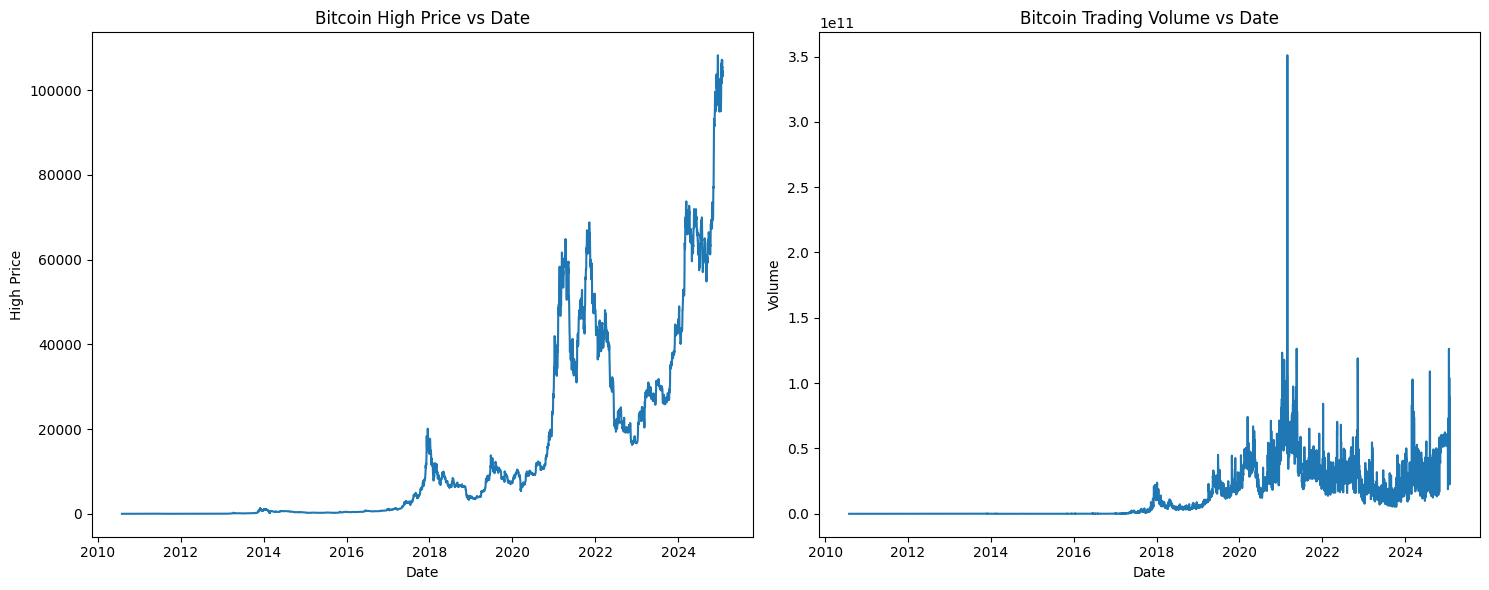

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.lineplot(x=df.index, y=df['High'])
plt.title('Bitcoin High Price vs Date')
plt.xlabel('Date')
plt.ylabel('High Price')

plt.subplot(1, 2, 2)
sns.lineplot(x=df.index, y=df['Volume'])
plt.title('Bitcoin Trading Volume vs Date')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.tight_layout()
plt.show()

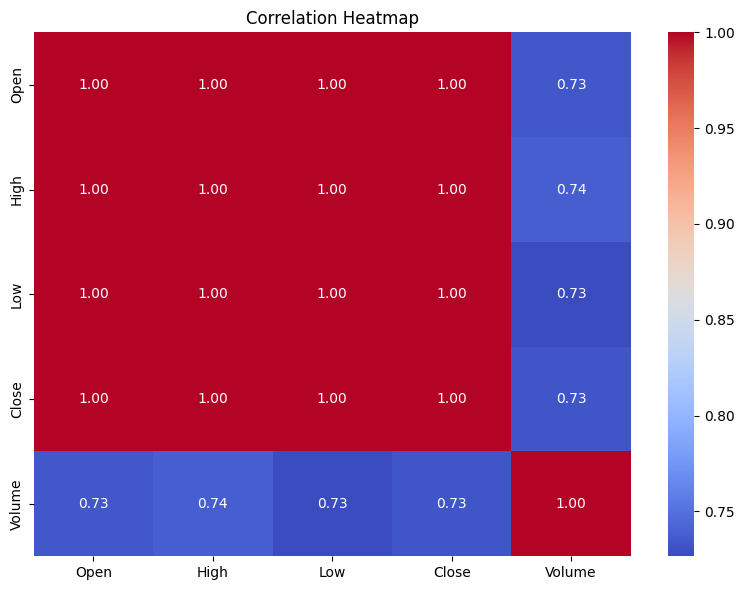

In [15]:
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 7))

plt.plot(df.index, df['High'], label='Bitcoin High Price')

plt.xlabel('Date')
plt.ylabel('High Price')
plt.title('Bitcoin High Price Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 4.1 Rolling Statistics

Rolling statistics are used to examine the local behavior of Bitcoin's High Price.

A 7-day rolling window is used to calculate:

- Rolling Mean — represents the short-term average price.
- Rolling Standard Deviation — represents short-term variability.

These statistics help identify changes in the level and variability of the series over time.

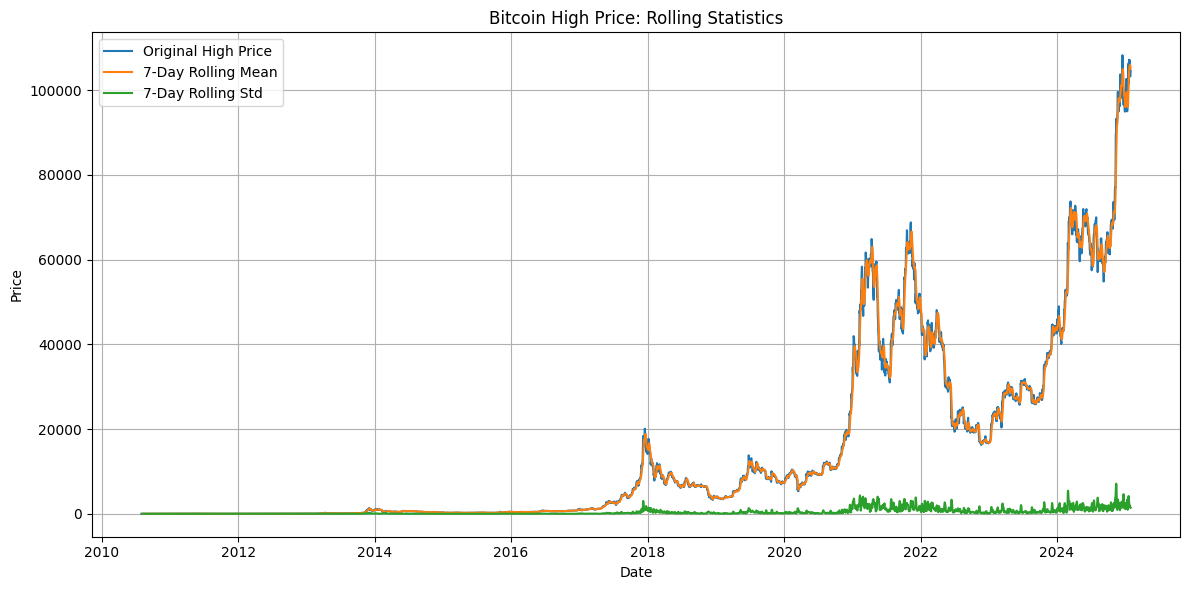

In [17]:
rolling_mean = df['High'].rolling(window=7).mean()
rolling_std = df['High'].rolling(window=7).std()

plt.figure(figsize=(12, 6))

plt.plot(df['High'], label='Original High Price')
plt.plot(rolling_mean, label='7-Day Rolling Mean')
plt.plot(rolling_std, label='7-Day Rolling Std')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Bitcoin High Price: Rolling Statistics')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Time Series Analysis

The Bitcoin High Price is treated as a daily time series.

The analysis investigates whether the series satisfies the assumptions required for statistical time-series modeling.

The following techniques are applied:

- Augmented Dickey-Fuller (ADF) test
- Seasonal decomposition
- Log transformation
- First-order differencing
- ACF and PACF analysis

In [18]:
ts = df['High'].copy()
print("Time series length:", len(ts))

Time series length: 5296


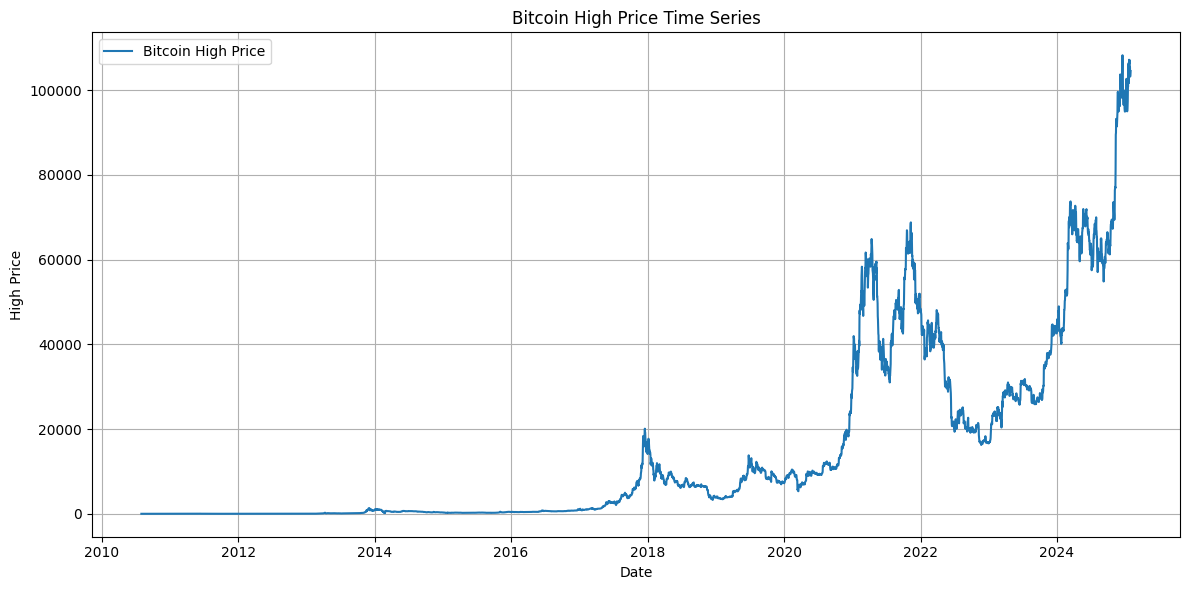

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(ts, label='Bitcoin High Price')

plt.xlabel('Date')
plt.ylabel('High Price')
plt.title('Bitcoin High Price Time Series')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5.1 Stationarity Analysis

Stationarity is an important requirement for several statistical time-series models.

The Augmented Dickey-Fuller (ADF) test is applied to determine whether the Bitcoin High Price series is stationary.

The null hypothesis of the ADF test states that the time series contains a unit root and is therefore non-stationary.

A p-value below 0.05 provides evidence against the null hypothesis.

In [20]:
adf_result = adfuller(ts.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Result: The series is stationary.")
else:
    print("Result: The series is non-stationary.")

ADF Statistic: 0.6171303042154629
p-value: 0.988030338456725
Result: The series is non-stationary.


### 5.2 Seasonal Decomposition

Seasonal decomposition is used to separate a time series into its main components:

- **Trend:** Represents the long-term direction or movement of the Bitcoin High price.
- **Seasonality:** Represents recurring patterns that occur at regular intervals.
- **Residual:** Represents the irregular or unexplained variations remaining after removing the trend and seasonal components.

The time series is decomposed using an additive model:

\[
Y_t = T_t + S_t + R_t
\]

where \(Y_t\) is the observed series, \(T_t\) is the trend component, \(S_t\) is the seasonal component, and \(R_t\) is the residual component.

Seasonal decomposition helps identify whether the Bitcoin High price contains any clear trend or repeating seasonal patterns before applying forecasting models.

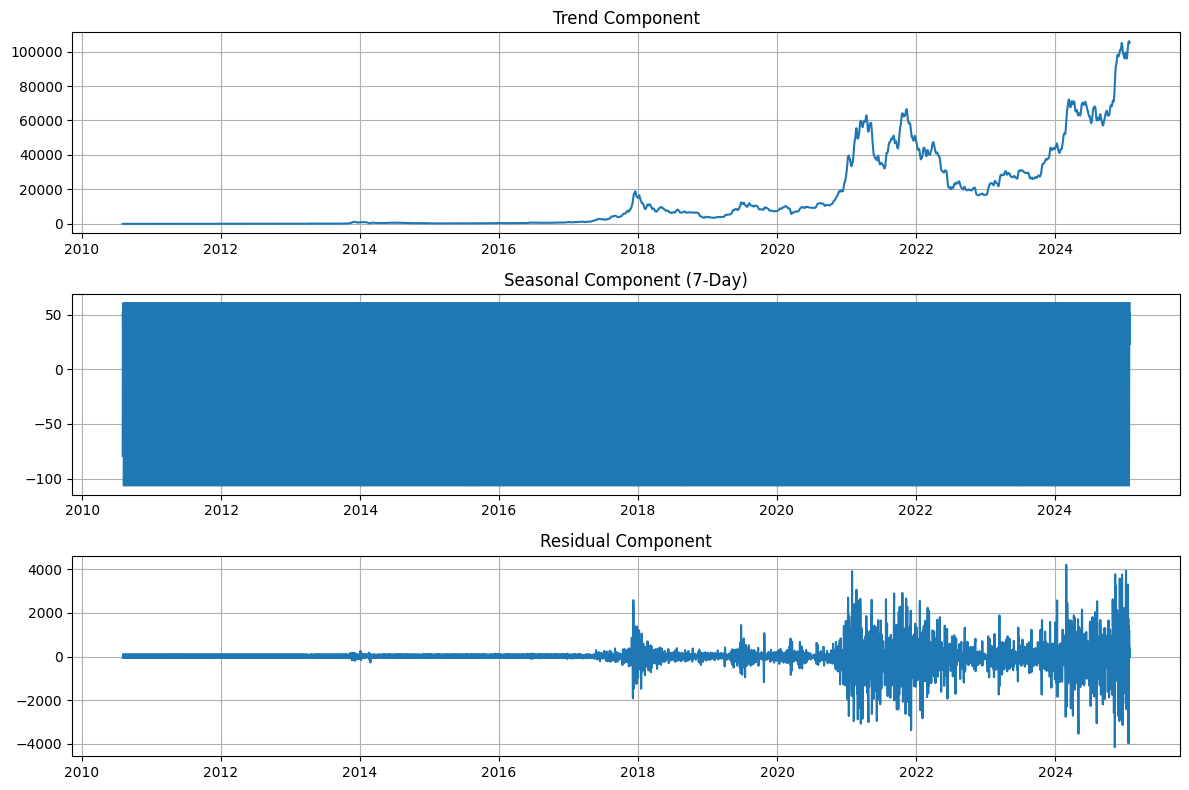

In [66]:
import statsmodels.api as sm
decomposition = sm.tsa.seasonal_decompose(ts, model='additive', period=7)
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(decomposition.trend)
plt.title('Trend Component')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(decomposition.seasonal)
plt.title('Seasonal Component (7-Day)')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(decomposition.resid)
plt.title('Residual Component')
plt.grid(True)

plt.tight_layout()
plt.show()

### 5.3 Log Transformation and Differencing

Because Bitcoin prices exhibit strong changes in scale over time, a logarithmic transformation is applied.

First-order differencing of the log-transformed series is then performed.

The resulting series can be interpreted as an approximation of daily logarithmic returns and is used for subsequent time-series analysis such as ACF, PACF, and volatility modeling.


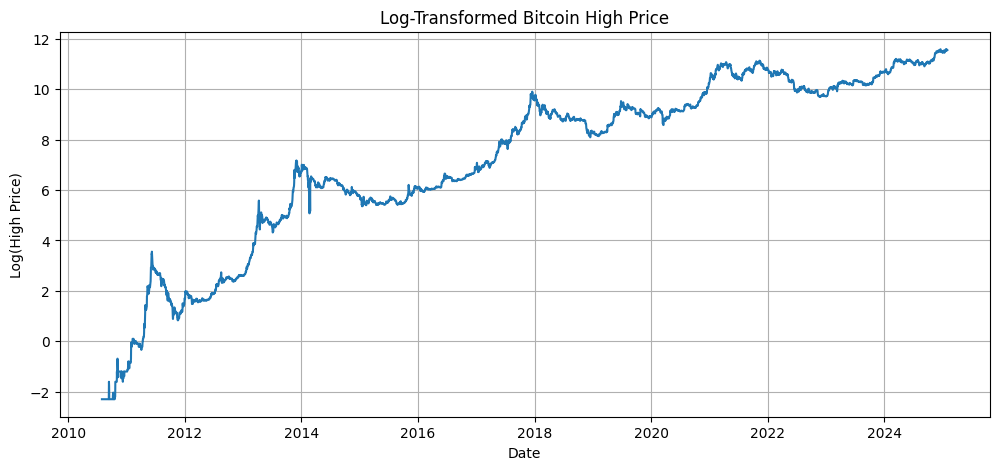

In [22]:
ts_log = np.log(ts)

plt.figure(figsize=(12, 5))
plt.plot(ts_log)
plt.title('Log-Transformed Bitcoin High Price')
plt.xlabel('Date')
plt.ylabel('Log(High Price)')
plt.grid(True)
plt.show()

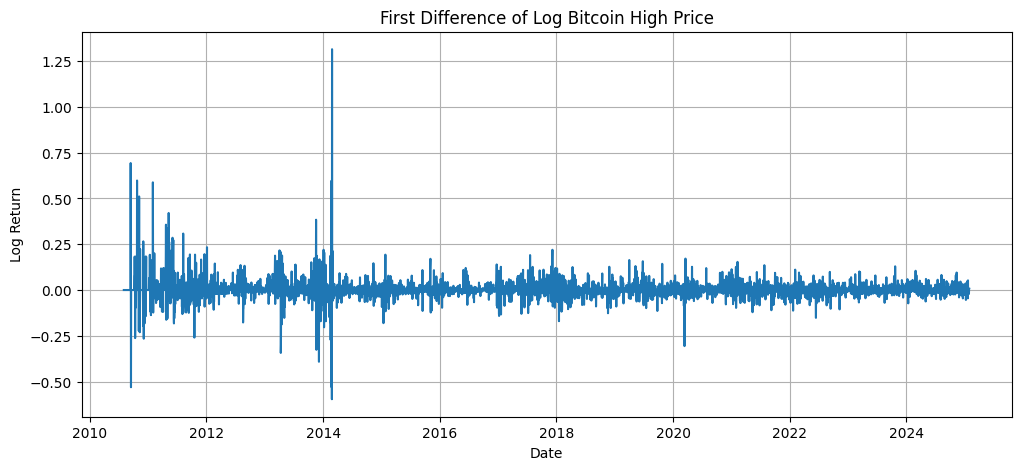

In [23]:
ts_diff = ts_log.diff().dropna()

plt.figure(figsize=(12, 5))
plt.plot(ts_diff)
plt.title('First Difference of Log Bitcoin High Price')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.grid(True)
plt.show()

In [24]:
adf_diff = adfuller(ts_diff)

print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

if adf_diff[1] < 0.05:
    print("Result: Differenced series is stationary.")
else:
    print("Result: Differenced series is still non-stationary.")

ADF Statistic: -11.686131164593917
p-value: 1.6954337331755608e-21
Result: Differenced series is stationary.


In [25]:
rolling_mean_diff = ts_diff.rolling(window=7).mean()
rolling_std_diff = ts_diff.rolling(window=7).std()

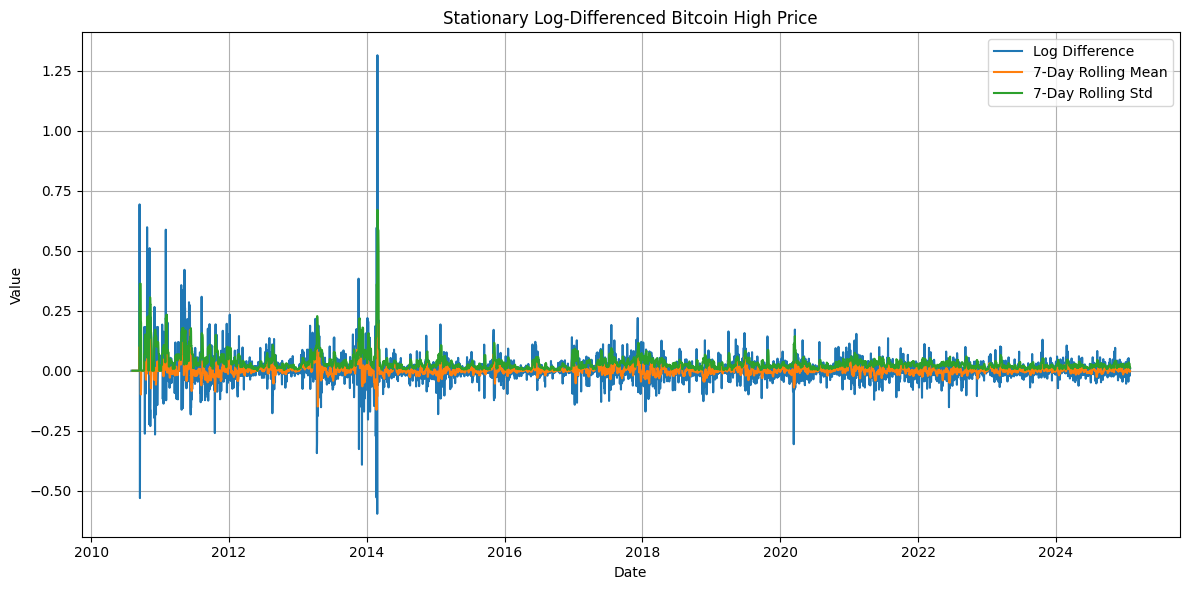

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(ts_diff, label='Log Difference')
plt.plot(rolling_mean_diff, label='7-Day Rolling Mean')
plt.plot(rolling_std_diff, label='7-Day Rolling Std')

plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Stationary Log-Differenced Bitcoin High Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5.4 Autocorrelation Analysis

The Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) are examined to understand the dependence structure of the differenced series.

These plots provide guidance for selecting autoregressive and moving-average components for ARIMA modeling.

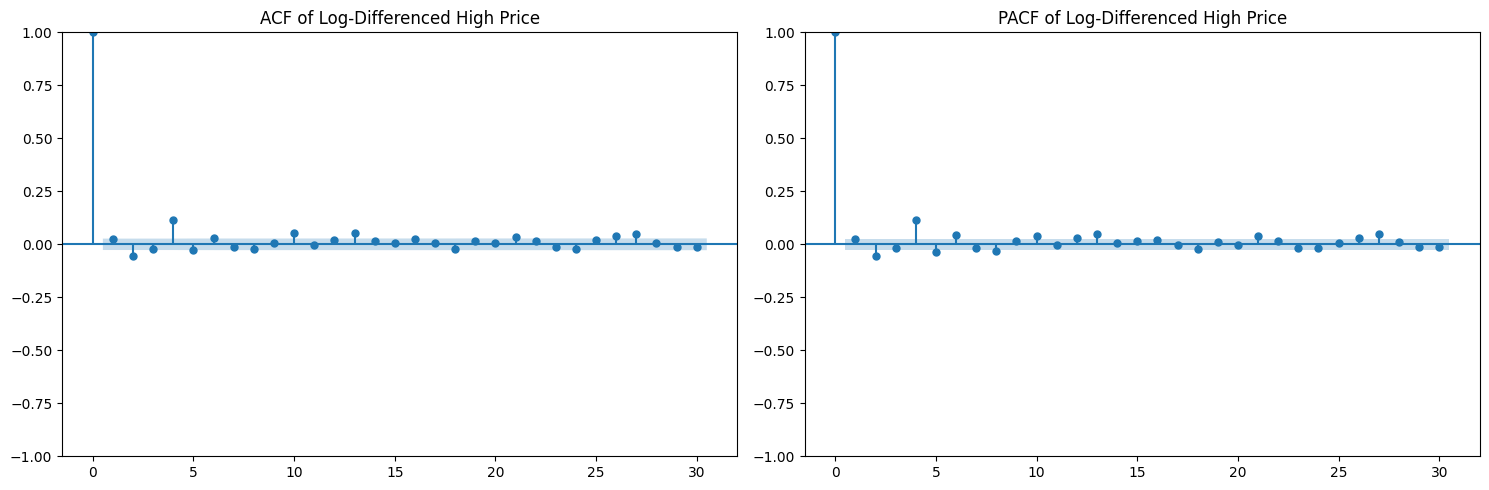

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(ts_diff.dropna(), ax=axes[0], lags=30)
axes[0].set_title('ACF of Log-Differenced High Price')

plot_pacf(ts_diff.dropna(), ax=axes[1], lags=30)
axes[1].set_title('PACF of Log-Differenced High Price')

plt.tight_layout()
plt.show()

## 6. Forecasting Models

In this section, different forecasting approaches are applied to predict the **Bitcoin High Price**. Both statistical time-series models and machine learning/deep learning models are considered to compare their predictive performance.

The following forecasting models are implemented:

- **ARIMA (AutoRegressive Integrated Moving Average):** A statistical time-series model used to capture autoregressive, differencing, and moving-average patterns in the Bitcoin High Price series.
- **Machine Learning Models:** XGBoost, LightGBM, and CatBoost are used to learn relationships between historical price features and the target High Price.
- **LSTM (Long Short-Term Memory):** A deep learning model designed to capture sequential and temporal dependencies in time-series data.

The models are evaluated using **Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² Score**. These metrics are used to compare the forecasting performance of the different approaches.

### 6.1 ARIMA Model

ARIMA is a statistical time-series forecasting model that combines autoregression, differencing, and moving-average components. It is applied to the Bitcoin High Price series to model its temporal dependencies and generate future price forecasts.

The dataset is divided chronologically into training and testing sets so that future observations are not used during model training.

In [28]:
train_size_arima = int(len(ts) * 0.8)

train_data_arima = ts.iloc[:train_size_arima]
test_data_arima = ts.iloc[train_size_arima:]

print(f"ARIMA training data size: {len(train_data_arima)}")
print(f"ARIMA testing data size: {len(test_data_arima)}")

ARIMA training data size: 4236
ARIMA testing data size: 1060


In [29]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train_data_arima, order=(5, 1, 0))
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   High   No. Observations:                 4236
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -32674.227
Date:                Tue, 15 Sep 2026   AIC                          65360.455
Time:                        10:16:56   BIC                          65398.562
Sample:                    08-01-2010   HQIC                         65373.924
                         - 03-06-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1256      0.006     21.918      0.000       0.114       0.137
ar.L2          0.0065      0.007      0.992      0.321      -0.006       0.019
ar.L3         -0.0434      0.006     -7.300      0.0

Now, let's make predictions on the test set and evaluate the model's performance.

In [30]:
predictions_arima = model_arima_fit.forecast(steps=len(test_data_arima))
predictions_arima.index = test_data_arima.index

mse_arima = mean_squared_error(test_data_arima, predictions_arima)
mae_arima = mean_absolute_error(test_data_arima, predictions_arima)
r2_arima = r2_score(test_data_arima, predictions_arima)

print(f"ARIMA MSE : {mse_arima:.2f}")
print(f"ARIMA MAE : {mae_arima:.2f}")
print(f"ARIMA R2  : {r2_arima:.4f}")

ARIMA MSE : 573336256.41
ARIMA MAE : 19108.20
ARIMA R2  : -0.0318


### ARIMA Model: Actual vs Predicted Bitcoin High Prices

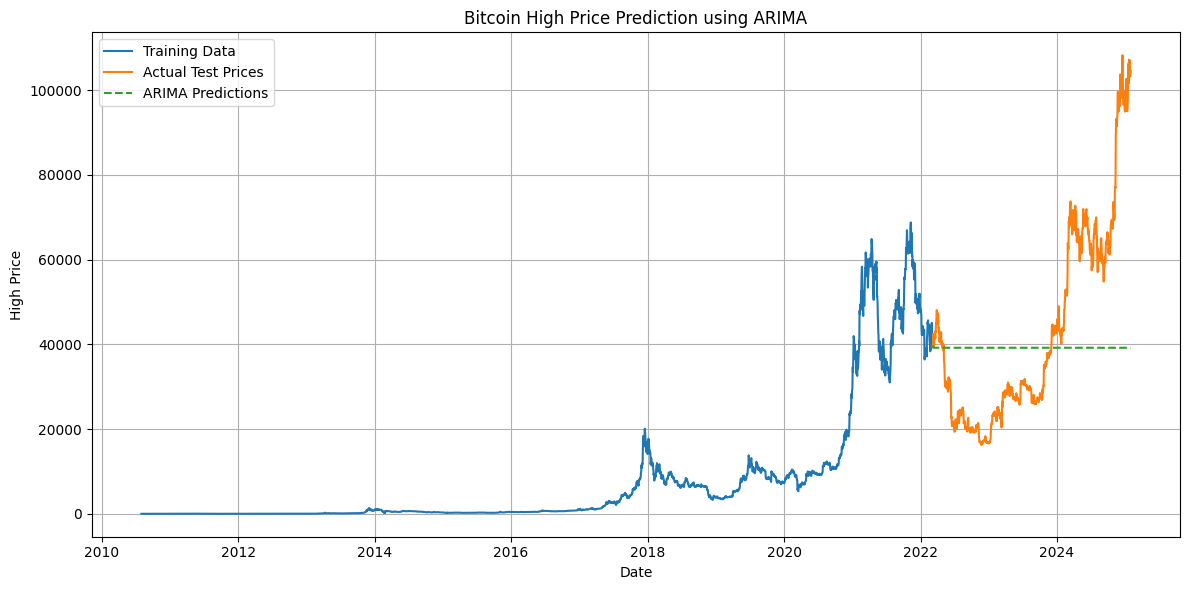

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(train_data_arima.index, train_data_arima, label='Training Data')
plt.plot(test_data_arima.index, test_data_arima, label='Actual Test Prices')
plt.plot(predictions_arima.index, predictions_arima, label='ARIMA Predictions', linestyle='--')

plt.title('Bitcoin High Price Prediction using ARIMA')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 6.2 Machine Learning Models

Machine learning regression models are used to predict the Bitcoin High Price using historical lagged price values and rolling statistical features.

The models considered are:

- XGBoost Regressor
- LightGBM Regressor
- CatBoost Regressor

Lag features and rolling statistics are constructed from previous observations to capture short-term and medium-term price patterns. The data is split chronologically into training and testing sets.

#### 6.2.1 Feature Engineering

To capture temporal dependencies, historical lag and rolling features are created.

##### Lag Features
- Lag 1
- Lag 2
- Lag 3
- Lag 7
- Lag 14
- Lag 30

##### Rolling Features
- 7-day rolling mean
- 14-day rolling mean
- 30-day rolling mean
- 7-day rolling standard deviation
- 14-day rolling standard deviation
- 30-day rolling standard deviation

The current day's High Price is used as the prediction target, while the features are derived from historical observations.

In [32]:
data_for_reg = df[['High']].copy()

# Lag features
for lag in [1, 2, 3, 7, 14, 30]:
    data_for_reg[f'Lag_{lag}'] = data_for_reg['High'].shift(lag)

# Rolling features
data_for_reg['Rolling_Mean_7'] = data_for_reg['High'].rolling(7).mean()
data_for_reg['Rolling_Mean_14'] = data_for_reg['High'].rolling(14).mean()
data_for_reg['Rolling_Mean_30'] = data_for_reg['High'].rolling(30).mean()

data_for_reg['Rolling_Std_7'] = data_for_reg['High'].rolling(7).std()
data_for_reg['Rolling_Std_14'] = data_for_reg['High'].rolling(14).std()
data_for_reg['Rolling_Std_30'] = data_for_reg['High'].rolling(30).std()

data_for_reg.dropna(inplace=True)


#### 6.2.2 Chronological Train-Test Split

For forecasting, random train-test splitting is avoided because it can cause future observations to influence the training process.

Instead, the observations are divided chronologically:

- **80% — Training data**
- **20% — Testing data**

The testing period is kept separate for final model evaluation.

In [33]:
# Features and target
X = data_for_reg.drop(columns=['High'])
y = data_for_reg['High']

# Chronological 80/20 split
train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4212, 12)
X_test : (1054, 12)
y_train: (4212,)
y_test : (1054,)


In [34]:
import sys
!{sys.executable} -m pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [35]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# ---------------- XGBoost ----------------
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# ---------------- LightGBM ----------------
lgb_model = LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, verbosity=-1)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

# ---------------- CatBoost ----------------
cat_model = CatBoostRegressor(iterations=200, learning_rate=0.05, depth=5, verbose=0, random_state=42)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)

# Evaluation
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

mse_lgb = mean_squared_error(y_test, y_pred_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)

mse_cat = mean_squared_error(y_test, y_pred_cat)
r2_cat = r2_score(y_test, y_pred_cat)

print(f"XGBoost  -> MSE: {mse_xgb:.2f}, R2: {r2_xgb:.4f}")
print(f"LightGBM -> MSE: {mse_lgb:.2f}, R2: {r2_lgb:.4f}")
print(f"CatBoost -> MSE: {mse_cat:.2f}, R2: {r2_cat:.4f}")

XGBoost  -> MSE: 113190012.56, R2: 0.7974
LightGBM -> MSE: 112271059.28, R2: 0.7991
CatBoost -> MSE: 114804525.62, R2: 0.7945


### 6.3 LSTM Model

Long Short-Term Memory (LSTM) is a recurrent neural network architecture designed to learn long-term dependencies in sequential data.

In this study, LSTM is used to model the temporal patterns in Bitcoin High Price data. The observations are transformed into sequential input windows using a specified look-back period. The model is trained on the training portion of the dataset and evaluated on unseen test observations.

X_train: (4229, 7)
X_test : (1060, 7, 1)
LSTM MSE : 57932087.81
LSTM MAE : 5703.84
LSTM R2  : 0.8957


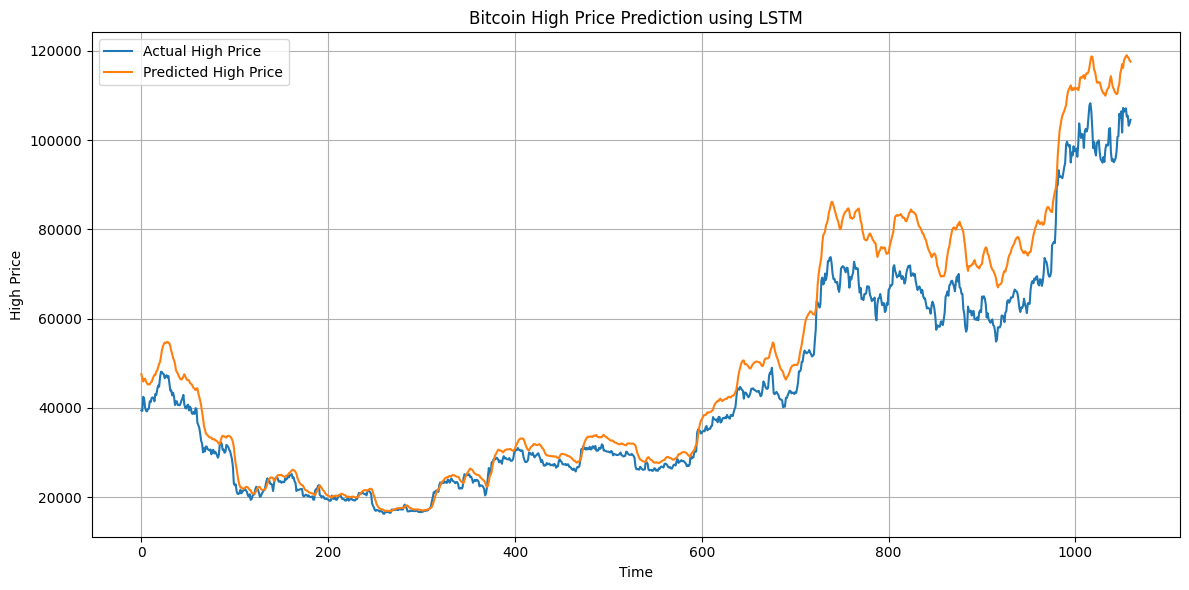

In [67]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

data = df['High'].values.reshape(-1, 1)
split_raw = int(len(data) * 0.8)

train_data = data[:split_raw]
test_data = data[split_raw:]

scaler_lstm = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler_lstm.fit_transform(train_data)
test_scaled = scaler_lstm.transform(test_data)

look_back = 7

X_train_lstm = []
y_train_lstm = []

for i in range(look_back, len(train_scaled)):
    X_train_lstm.append(train_scaled[i-look_back:i, 0])
    y_train_lstm.append(train_scaled[i, 0])

# Test sequences need the last 7 training observations
combined_test_data = np.concatenate([train_scaled[-look_back:], test_scaled])

X_test_lstm = []
y_test_lstm = []

for i in range(look_back, len(combined_test_data)):
    X_test_lstm.append(combined_test_data[i-look_back:i, 0])
    y_test_lstm.append(combined_test_data[i, 0])

X_train_lstm = np.array(X_train_lstm)
y_train_lstm = np.array(y_train_lstm)

X_test_lstm = np.array(X_test_lstm)
y_test_lstm = np.array(y_test_lstm)

# Reshape for LSTM
X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0],X_train_lstm.shape[1],)
X_test_lstm = X_test_lstm.reshape(X_test_lstm.shape[0], X_test_lstm.shape[1], 1)

print("X_train:", X_train_lstm.shape)
print("X_test :", X_test_lstm.shape)

model = Sequential([LSTM( 50, return_sequences=True, input_shape=(look_back, 1)), LSTM(50), Dense(1)])
model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=32, validation_split=0.1, shuffle=False, verbose=0)
predicted = model.predict(X_test_lstm, verbose=0)
predicted_prices = scaler_lstm.inverse_transform(predicted)
real_prices = scaler_lstm.inverse_transform(y_test_lstm.reshape(-1, 1))

mse_lstm = mean_squared_error(real_prices, predicted_prices)
mae_lstm = mean_absolute_error(real_prices, predicted_prices)
r2_lstm = r2_score(real_prices, predicted_prices)

print(f"LSTM MSE : {mse_lstm:.2f}")
print(f"LSTM MAE : {mae_lstm:.2f}")
print(f"LSTM R2  : {r2_lstm:.4f}")

# Plot

plt.figure(figsize=(12, 6))
plt.plot(real_prices, label='Actual High Price')
plt.plot(predicted_prices, label='Predicted High Price')

plt.title('Bitcoin High Price Prediction using LSTM')
plt.xlabel('Time')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 6.4 Hyperparameter Optimization

Hyperparameter tuning is performed to improve the performance of the machine learning and ARIMA models.

RandomizedSearchCV is used for:

- XGBoost
- LightGBM
- CatBoost

Because the dataset is time-dependent, **TimeSeriesSplit** is used during cross-validation instead of random cross-validation.

For ARIMA, Auto-ARIMA is used to identify a suitable model order based on the training data.

In [37]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint, uniform

In [38]:
# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=3)

xgb_params = {'n_estimators': randint(100, 500), 'learning_rate': uniform(0.01, 0.10), 'max_depth': randint(3, 10), 'subsample': uniform(0.6, 0.4),
              'colsample_bytree': uniform(0.6, 0.4)}

xgb_search = RandomizedSearchCV(estimator=XGBRegressor(random_state=42), param_distributions=xgb_params, n_iter=50, cv=tscv,
                                scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)

print("Tuning XGBoost...")
xgb_search.fit(X_train, y_train)
print("Best XGBoost parameters:")
print(xgb_search.best_params_)

best_xgb_model = xgb_search.best_estimator_
y_pred_xgb_tuned = best_xgb_model.predict(X_test)
mse_xgb_tuned = mean_squared_error(y_test, y_pred_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print(f"Tuned XGBoost -> "
    f"MSE: {mse_xgb_tuned:.2f}, "
    f"R2: {r2_xgb_tuned:.4f}")

Tuning XGBoost...
Best XGBoost parameters:
{'colsample_bytree': np.float64(0.6478376983753207), 'learning_rate': np.float64(0.0813244787222995), 'max_depth': 3, 'n_estimators': 104, 'subsample': np.float64(0.8245108790277985)}
Tuned XGBoost -> MSE: 109371318.58, R2: 0.8043


In [39]:
lgb_params = {'n_estimators': randint(100, 500), 'learning_rate': uniform(0.01, 0.10), 'max_depth': randint(3, 10),
              'subsample': uniform(0.6, 0.4), 'colsample_bytree': uniform(0.6, 0.4)}

lgb_search = RandomizedSearchCV(estimator=LGBMRegressor(random_state=42, verbosity=-1), param_distributions=lgb_params, n_iter=50, cv=tscv,
                                scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)

print("Tuning LightGBM...")
lgb_search.fit(X_train, y_train)
print("Best LightGBM parameters:")
print(lgb_search.best_params_)

best_lgb_model = lgb_search.best_estimator_
y_pred_lgb_tuned = best_lgb_model.predict(X_test)
mse_lgb_tuned = mean_squared_error(y_test, y_pred_lgb_tuned)
r2_lgb_tuned = r2_score(y_test, y_pred_lgb_tuned)

print(f"Tuned LightGBM -> "
    f"MSE: {mse_lgb_tuned:.2f}, "
    f"R2: {r2_lgb_tuned:.4f}")

Tuning LightGBM...
Best LightGBM parameters:
{'colsample_bytree': np.float64(0.9530545372757359), 'learning_rate': np.float64(0.02887071083413794), 'max_depth': 3, 'n_estimators': 198, 'subsample': np.float64(0.8801431319891084)}
Tuned LightGBM -> MSE: 111899585.71, R2: 0.7997


In [41]:
cat_params = {'iterations': randint(100, 500), 'learning_rate': uniform(0.01, 0.10), 'depth': randint(3, 10), 'subsample': uniform(0.6, 0.4)}

cat_search = RandomizedSearchCV(estimator=CatBoostRegressor(random_state=42, verbose=0), param_distributions=cat_params, n_iter=50,
                                cv=tscv, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)

print("Tuning CatBoost...")
cat_search.fit(X_train, y_train)
print("Best CatBoost parameters:")
print(cat_search.best_params_)

best_cat_model = cat_search.best_estimator_
y_pred_cat_tuned = best_cat_model.predict(X_test)
mse_cat_tuned = mean_squared_error(y_test, y_pred_cat_tuned)
r2_cat_tuned = r2_score(y_test, y_pred_cat_tuned)

print(f"Tuned CatBoost -> "
    f"MSE: {mse_cat_tuned:.2f}, "
    f"R2: {r2_cat_tuned:.4f}")

Tuning CatBoost...
Best CatBoost parameters:
{'depth': 3, 'iterations': 279, 'learning_rate': np.float64(0.0463629602379294), 'subsample': np.float64(0.9887128330883843)}
Tuned CatBoost -> MSE: 107454892.50, R2: 0.8077


In [43]:
import sys
!{sys.executable} -m pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 9.6 MB/s eta 0:00:00


In [63]:
import pmdarima as pm

print("Tuning ARIMA using Auto-ARIMA...")
auto_arima_model = pm.auto_arima(train_data_arima, seasonal=False, stepwise=True, suppress_warnings=True,
                                 error_action='ignore', trace=True)
print("Best ARIMA order:", auto_arima_model.order)
predictions_arima_tuned = auto_arima_model.predict(n_periods=len(test_data_arima))
predictions_arima_tuned = pd.Series(predictions_arima_tuned, index=test_data_arima.index)

mse_arima_tuned = mean_squared_error(test_data_arima, predictions_arima_tuned)
mae_arima_tuned = mean_absolute_error(test_data_arima, predictions_arima_tuned)
r2_arima_tuned = r2_score(test_data_arima, predictions_arima_tuned)

print(f"Tuned ARIMA -> "
    f"MSE: {mse_arima_tuned:.2f}, "
    f"R2: {r2_arima_tuned:.4f}")

Tuning ARIMA using Auto-ARIMA...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=65381.436, Time=3.23 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=65457.878, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=65394.984, Time=0.18 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=65396.888, Time=0.48 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=65457.107, Time=0.09 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=65370.967, Time=3.02 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=65395.847, Time=0.69 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=65396.968, Time=0.47 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=65370.866, Time=5.30 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=65387.458, Time=0.93 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=65372.849, Time=6.85 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=65365.775, Time=7.33 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=65366.939, Time=1.14 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=65363.476, 

### 6.5  Tuned Model Predictions
  

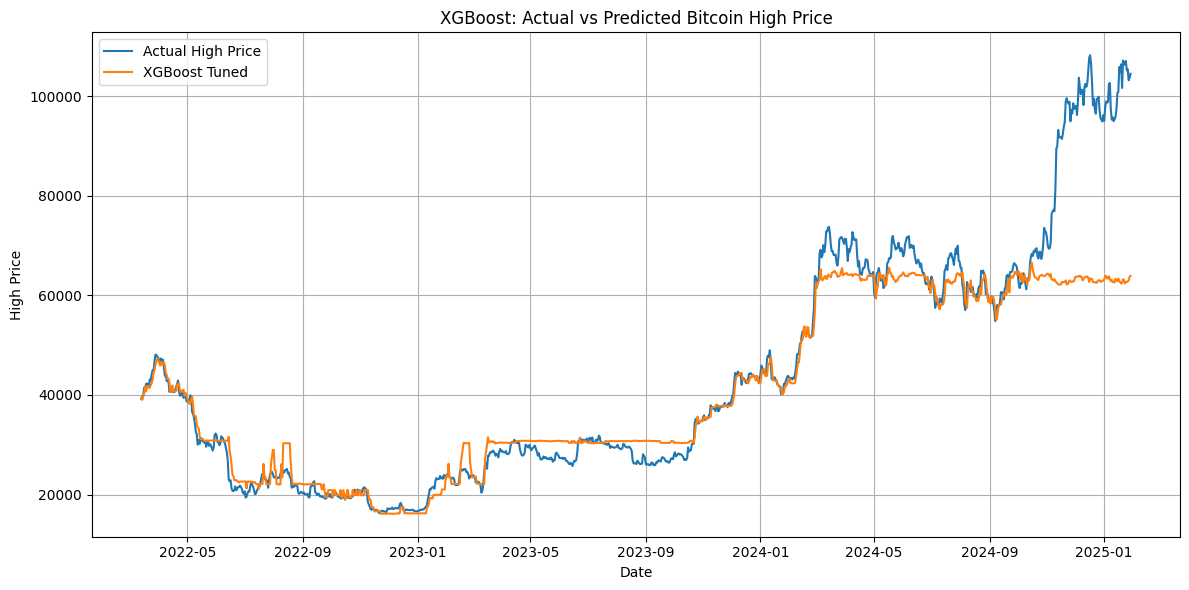

In [45]:
# XGBoost
plt.figure(figsize=(12, 6))

plt.plot(y_test.index, y_test, label='Actual High Price')
plt.plot(y_test.index, y_pred_xgb_tuned, label='XGBoost Tuned')

plt.title('XGBoost: Actual vs Predicted Bitcoin High Price')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

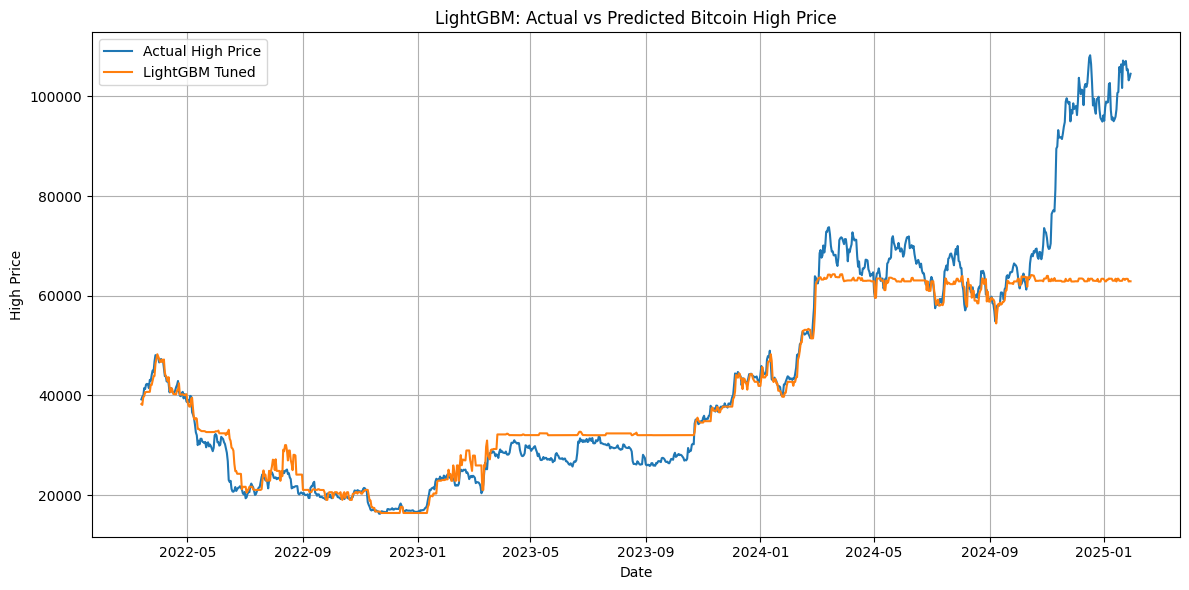

In [46]:
# LightGBM
plt.figure(figsize=(12, 6))

plt.plot(y_test.index, y_test, label='Actual High Price')
plt.plot(y_test.index, y_pred_lgb_tuned, label='LightGBM Tuned')

plt.title('LightGBM: Actual vs Predicted Bitcoin High Price')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

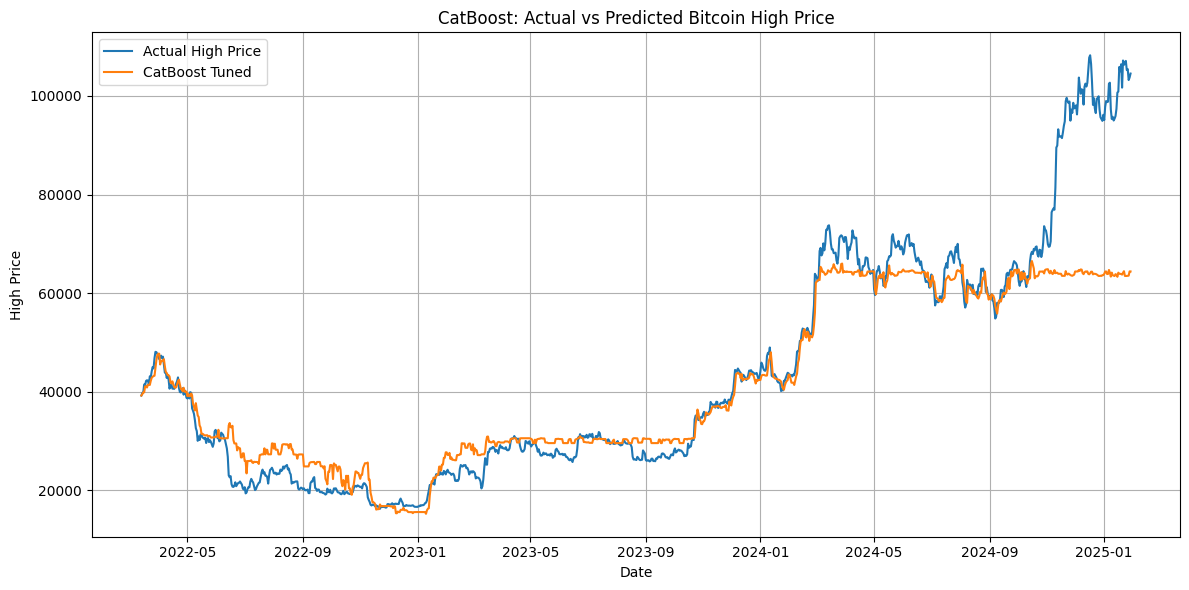

In [47]:
# CatBoost
plt.figure(figsize=(12, 6))

plt.plot(y_test.index, y_test, label='Actual High Price')
plt.plot(y_test.index, y_pred_cat_tuned, label='CatBoost Tuned')

plt.title('CatBoost: Actual vs Predicted Bitcoin High Price')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

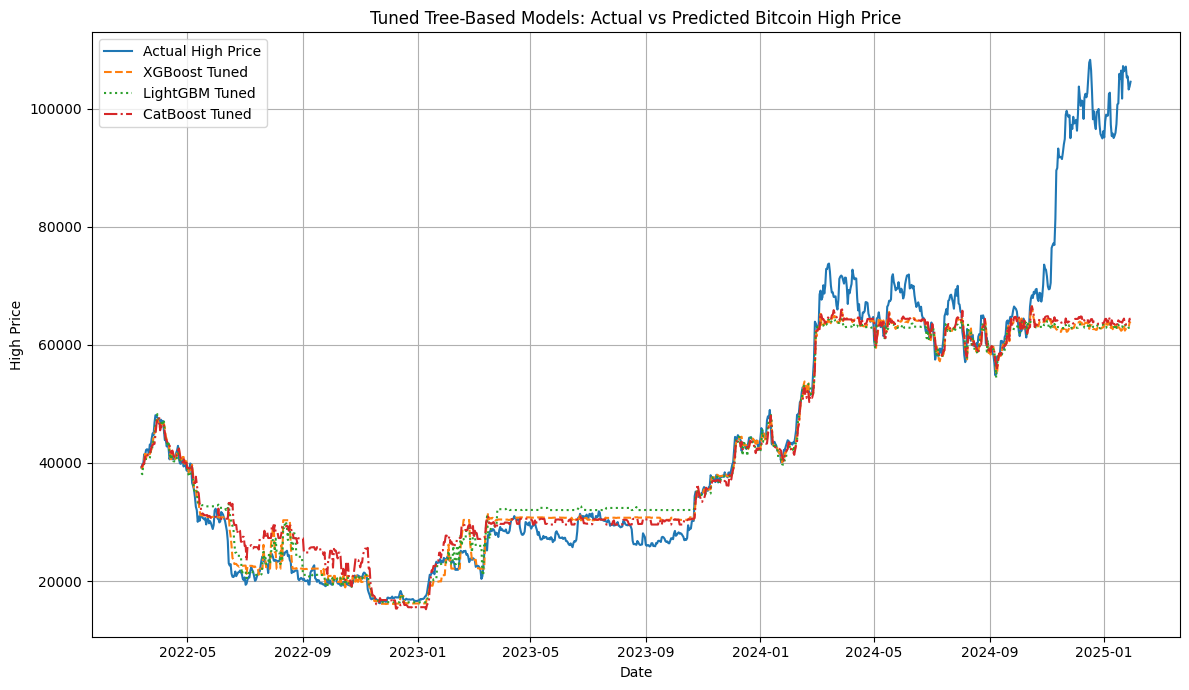

In [48]:
plt.figure(figsize=(12, 7))

plt.plot(y_test.index, y_test, label='Actual High Price')
plt.plot(y_test.index, y_pred_xgb_tuned, label='XGBoost Tuned', linestyle='--')
plt.plot(y_test.index, y_pred_lgb_tuned, label='LightGBM Tuned', linestyle=':')
plt.plot(y_test.index, y_pred_cat_tuned, label='CatBoost Tuned', linestyle='-.')

plt.title('Tuned Tree-Based Models: Actual vs Predicted Bitcoin High Price')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#####  Tuned ARIMA Model: Actual vs Predicted Bitcoin High Price

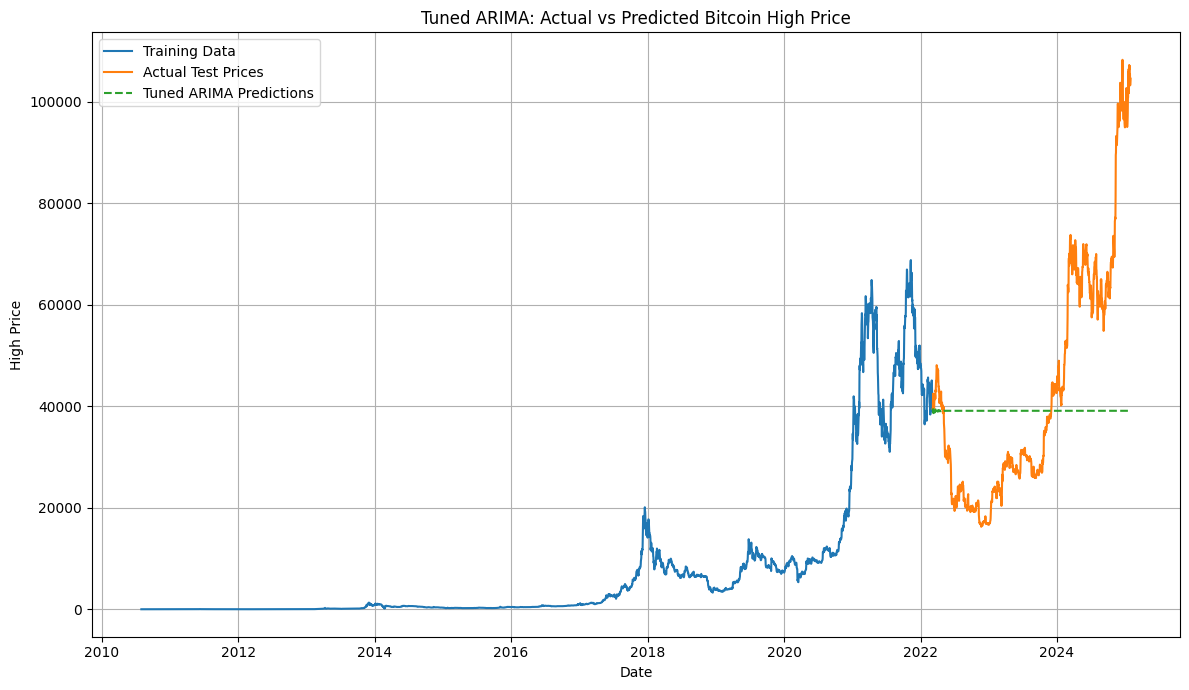

In [49]:
plt.figure(figsize=(12, 7))

plt.plot(train_data_arima.index, train_data_arima, label='Training Data')
plt.plot(test_data_arima.index, test_data_arima, label='Actual Test Prices')
plt.plot(predictions_arima_tuned.index, predictions_arima_tuned, label='Tuned ARIMA Predictions', linestyle='--')

plt.title('Tuned ARIMA: Actual vs Predicted Bitcoin High Price')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Anomaly Detection

In addition to price forecasting, the project investigates unusual market behavior using multiple anomaly-detection approaches.

The following techniques are considered:

1. Isolation Forest
2. Hidden Markov Model (HMM)
3. LSTM Autoencoder

These approaches identify observations or periods that exhibit behavior substantially different from the learned normal patterns.

### 7.1 Isolation Forest

Isolation Forest is an unsupervised anomaly-detection algorithm based on the principle that unusual observations are easier to isolate than normal observations.

The model is applied to Bitcoin High Price observations to identify potentially unusual price levels.

Detected anomalies are visualized against the historical Bitcoin High Price series.

Training Isolation Forest...
Detected anomalies: 52


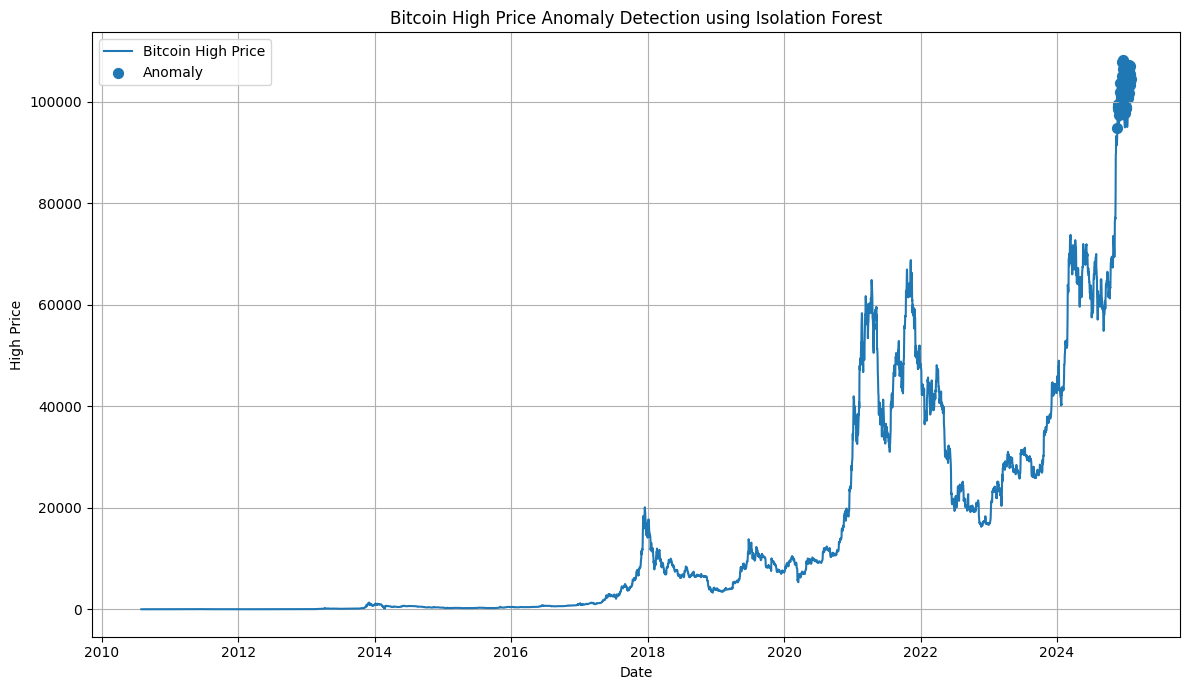

In [50]:
from sklearn.ensemble import IsolationForest

data_if = df[['High']].copy()
model_if = IsolationForest(random_state=42, contamination=0.01)

print("Training Isolation Forest...")
data_if['anomaly'] = model_if.fit_predict(data_if[['High']])
anomalies = data_if[data_if['anomaly'] == -1]
print(f"Detected anomalies: {len(anomalies)}")

plt.figure(figsize=(12, 7))
plt.plot(data_if.index, data_if['High'], label='Bitcoin High Price')
plt.scatter(anomalies.index, anomalies['High'], label='Anomaly', s=50)

plt.title('Bitcoin High Price Anomaly Detection using Isolation Forest')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 7.2  Hidden Markov Model

A Gaussian Hidden Markov Model (HMM) is used to identify different latent market states based on Bitcoin price-return behavior.

The model assumes that observations are generated from a finite number of hidden states.

Observations with unusually low likelihood under the learned state distributions are considered potential anomalies.

The identified anomalous observations are visualized on the Bitcoin High Price series.

In [51]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.3 MB/s eta 0:00:00


In [52]:
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler

# Use log returns
hmm_data = np.log(df['High']).diff().dropna().values.reshape(-1, 1)
scaler_hmm = StandardScaler()
scaled_hmm = scaler_hmm.fit_transform(hmm_data)

print("HMM data shape:", scaled_hmm.shape)

HMM data shape: (5295, 1)


In [53]:
model_hmm = hmm.GaussianHMM(n_components=4, covariance_type='diag', n_iter=200, random_state=42)

print("Training HMM...")
model_hmm.fit(scaled_hmm)
print("HMM training complete.")

Training HMM...
HMM training complete.


In [54]:
# Get the most likely hidden state for each observation
hidden_states = model_hmm.predict(scaled_hmm)

# Calculate log-likelihood for each observation
emission_log_probs = model_hmm._compute_log_likelihood(scaled_hmm)

# Select the likelihood corresponding to the predicted state
log_likelihoods = emission_log_probs[np.arange(len(scaled_hmm)), hidden_states]

# Define anomaly threshold using the lowest 5% likelihoods
threshold_hmm = np.percentile(log_likelihoods, 5)

# Boolean anomaly mask
anomalies_hmm = log_likelihoods < threshold_hmm

# Dates correspond to log returns, which start one day after the original data
hmm_dates = df.index[1:]

# Select anomaly dates
anomaly_dates_hmm = hmm_dates[anomalies_hmm]

# Select corresponding prices
anomaly_prices_hmm = df['High'].iloc[1:].iloc[anomalies_hmm]

print(f"Detected {anomalies_hmm.sum()} HMM anomalies.")
print(f"Log-likelihood threshold: {threshold_hmm:.4f}")

Detected 265 HMM anomalies.
Log-likelihood threshold: -2.4367


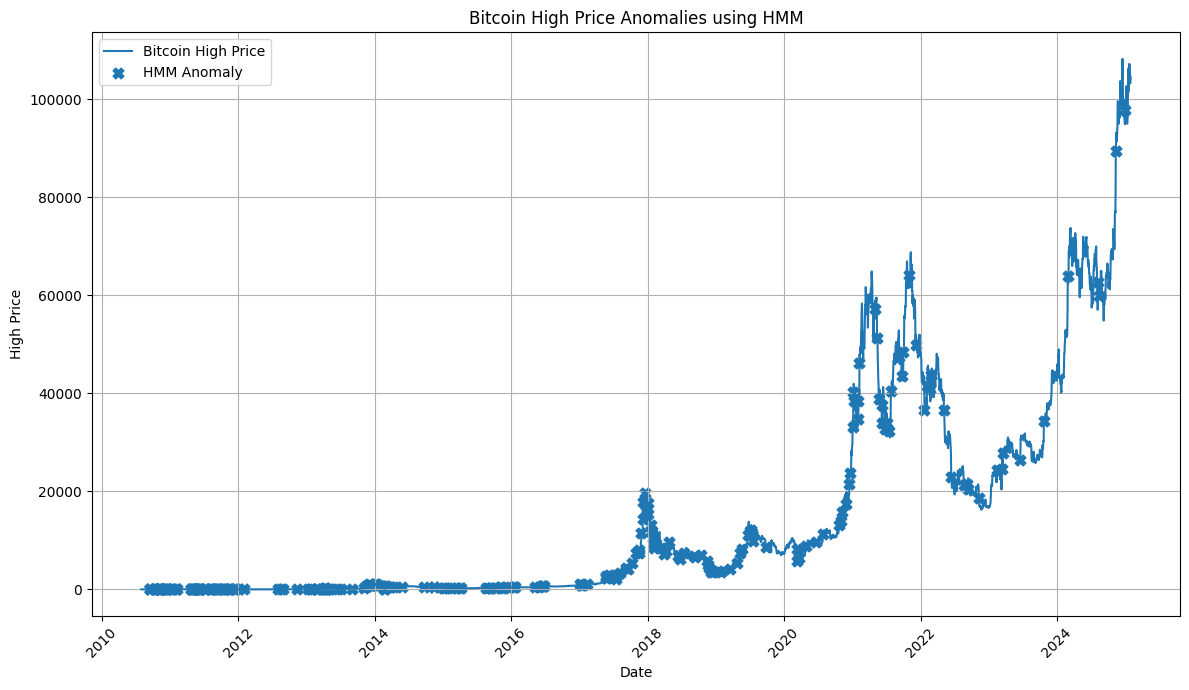

In [55]:
plt.figure(figsize=(12, 7))

plt.plot(df.index, df['High'], label='Bitcoin High Price')
plt.scatter(anomaly_dates_hmm, anomaly_prices_hmm, label='HMM Anomaly', s=60, marker='X')

plt.title('Bitcoin High Price Anomalies using HMM')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7.3 LSTM Autoencoder for Anomaly Detection

An LSTM Autoencoder is used to identify unusual temporal patterns in Bitcoin High Price behavior.

The autoencoder learns to reconstruct normal sequences of historical prices.

The reconstruction error is used as an anomaly score:

- Low reconstruction error → behavior similar to learned patterns
- High reconstruction error → potentially anomalous behavior

A threshold based on the reconstruction-error distribution is used to identify potential anomalies in the testing period.

Training sequences: (4206, 30, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │           129 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,273 (774.50 KB)

 Trainable params: 198,273 (774.50 KB)

 Non-trainable params: 0 (0.00 B)

Autoencoder training complete.
Reconstruction error threshold: 0.066830
Detected 331 anomalies.


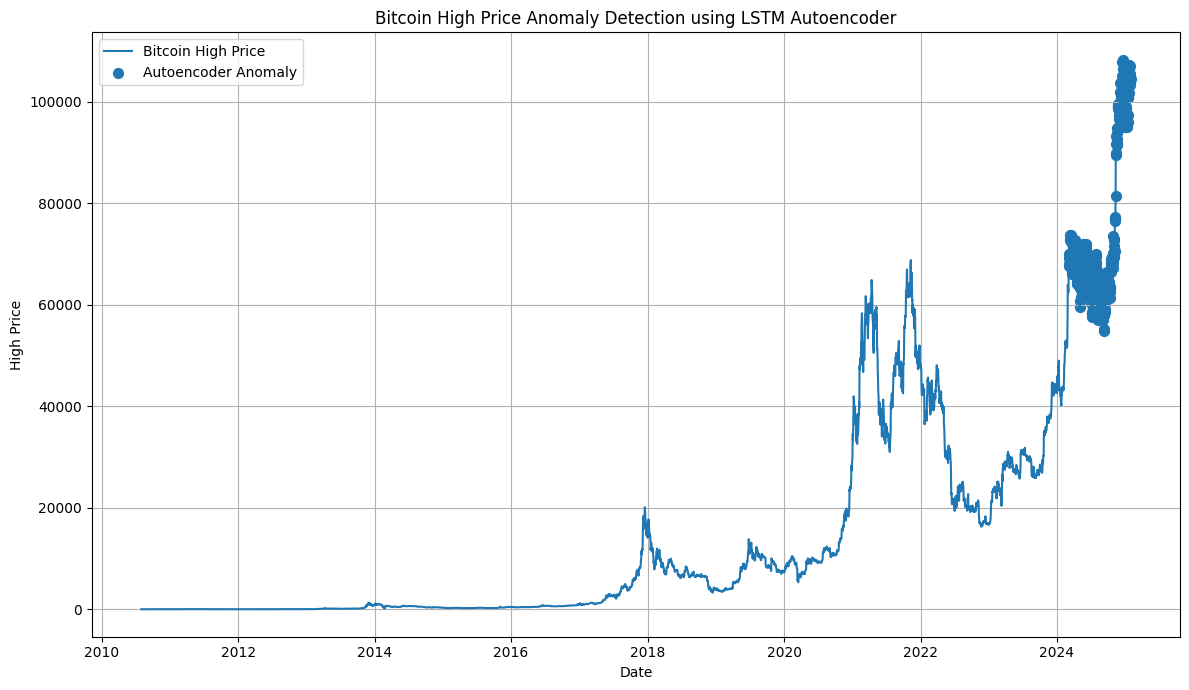

In [56]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense

# 1. Data

data_ae = df['High'].values.reshape(-1, 1)
sequence_length_ae = 30

# 2. Chronological split

split_raw_ae = int(len(data_ae) * 0.8)
train_raw_ae = data_ae[:split_raw_ae]
test_raw_ae = data_ae[split_raw_ae:]

# 3. Scale using training data only

scaler_ae = MinMaxScaler(feature_range=(0, 1))
train_scaled_ae = scaler_ae.fit_transform(train_raw_ae)
test_scaled_ae = scaler_ae.transform(test_raw_ae)

# 4. Create training sequences

X_ae_train = []
for i in range(len(train_scaled_ae) - sequence_length_ae):
    X_ae_train.append(train_scaled_ae[i:i + sequence_length_ae, 0])

X_ae_train = np.array(X_ae_train)
X_ae_train = X_ae_train.reshape(X_ae_train.shape[0], X_ae_train.shape[1],1)
print("Training sequences:", X_ae_train.shape)

# 5. Autoencoder

model_ae = Sequential([LSTM(128, activation='tanh', input_shape=(sequence_length_ae, 1)), RepeatVector(sequence_length_ae), LSTM(128, activation='tanh', return_sequences=True), TimeDistributed(Dense(1))])
model_ae.compile(optimizer='adam', loss='mse')
model_ae.summary()

# 6. Train

history_ae = model_ae.fit(X_ae_train, X_ae_train, epochs=50, batch_size=32, validation_split=0.1, shuffle=False, verbose=0)
print("Autoencoder training complete.")

# 7. Reconstruction error on TRAINING data

train_predictions_ae = model_ae.predict(X_ae_train, verbose=0)
train_errors = np.mean(np.square(X_ae_train - train_predictions_ae), axis=(1, 2))

# 8. Threshold

threshold = np.percentile(train_errors, 95)
print(f"Reconstruction error threshold: {threshold:.6f}")

# 9. Create test sequences

combined_ae = np.concatenate([train_scaled_ae[-sequence_length_ae:], test_scaled_ae])
X_ae_test = []

for i in range(sequence_length_ae, len(combined_ae)):
    X_ae_test.append(combined_ae[i-sequence_length_ae:i, 0])

X_ae_test = np.array(X_ae_test)
X_ae_test = X_ae_test.reshape(X_ae_test.shape[0], X_ae_test.shape[1],1)

# 10. Test reconstruction

test_predictions_ae = model_ae.predict(X_ae_test, verbose=0)
test_errors = np.mean(np.square(X_ae_test - test_predictions_ae),axis=(1, 2))
anomalies_index = np.where(test_errors > threshold)[0]

# 11. Map anomalies to dates

test_dates = df.index[split_raw_ae:]
anomaly_dates = test_dates[anomalies_index]
anomaly_prices = df['High'].iloc[split_raw_ae:].iloc[anomalies_index]
print(f"Detected {len(anomalies_index)} anomalies.")

# 12. Plot

plt.figure(figsize=(12, 7))
plt.plot(df.index, df['High'], label='Bitcoin High Price')
plt.scatter(anomaly_dates, anomaly_prices, label='Autoencoder Anomaly', s=50)
plt.title('Bitcoin High Price Anomaly Detection using LSTM Autoencoder')

plt.xlabel('Date')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 8. Volatility Modeling using GARCH

The Generalized Autoregressive Conditional Heteroskedasticity (GARCH) model is used to analyze the volatility of Bitcoin High-Price returns.

A GARCH(1,1) model is fitted to the return series to estimate time-varying conditional volatility.

The model is then used to generate short-term volatility forecasts.

This analysis complements price prediction by examining the changing risk and variability of the Bitcoin market.

#### 8.1 GARCH(1,1)

In [57]:
!pip install -q arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 14.3 MB/s eta 0:00:00


In [58]:
from arch import arch_model
returns = 100 * df['High'].pct_change().dropna()

print("Returns data shape:", returns.shape)
display(returns.head())

Returns data shape: (5295,)


,High
Date,
2010-08-02,0.0
2010-08-03,0.0
2010-08-04,0.0
2010-08-05,0.0
2010-08-06,0.0


In [59]:
from arch import arch_model

garch_model = arch_model(returns, mean='Constant', vol='GARCH', p=1, q=1, dist='normal')
print("Training GARCH(1,1) model...")

garch_result = garch_model.fit(disp='off')
print("GARCH model training complete.")
print(garch_result.summary())

Training GARCH(1,1) model...
GARCH model training complete.
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   High   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -15191.2
Distribution:                  Normal   AIC:                           30390.4
Method:            Maximum Likelihood   BIC:                           30416.7
                                        No. Observations:                 5295
Date:                Tue, Sep 15 2026   Df Residuals:                     5294
Time:                        11:00:27   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu        

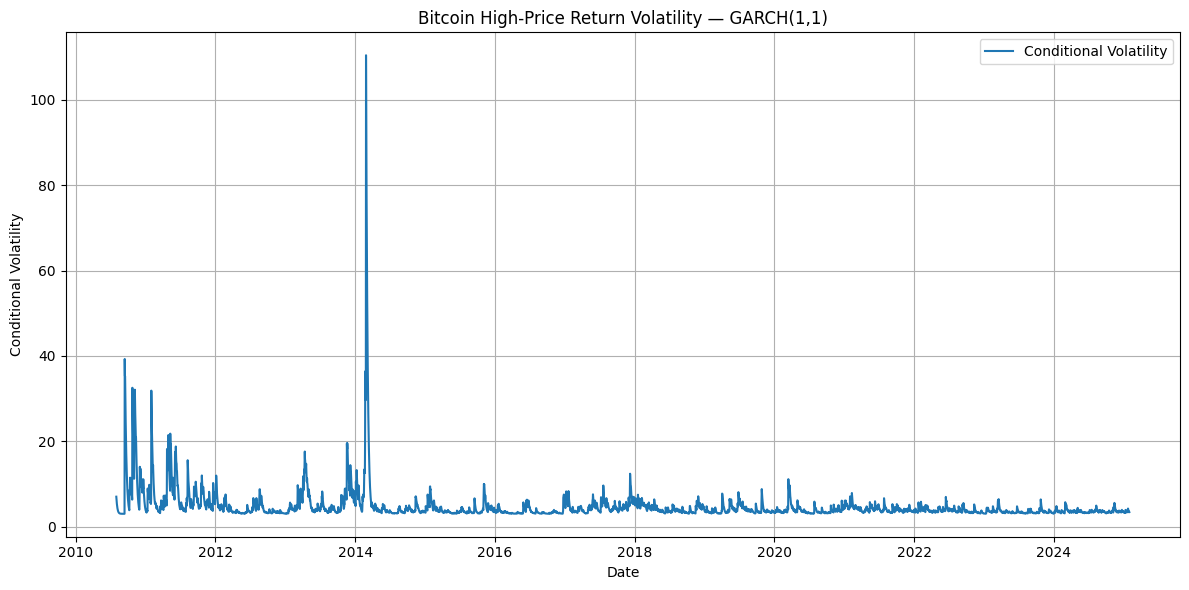

In [60]:
conditional_volatility = garch_result.conditional_volatility

plt.figure(figsize=(12, 6))
plt.plot(conditional_volatility.index, conditional_volatility, label='Conditional Volatility')

plt.title('Bitcoin High-Price Return Volatility — GARCH(1,1)')
plt.xlabel('Date')
plt.ylabel('Conditional Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [61]:
forecasts = garch_result.forecast(horizon=5)

future_volatility = np.sqrt(forecasts.variance.iloc[-1].values)
future_dates = pd.date_range(start=returns.index[-1] + pd.Timedelta(days=1), periods=5, freq='D')

print("Forecasted Conditional Volatility:")
print()

for date, vol in zip(future_dates, future_volatility):
    print(f"{date.strftime('%Y-%m-%d')}: {vol:.4f}")

Forecasted Conditional Volatility:

2025-01-30: 3.3515
2025-01-31: 3.5363
2025-02-01: 3.7012
2025-02-02: 3.8494
2025-02-03: 3.9834


## 9. Model Evaluation
The forecasting models are evaluated using the following metrics:

### Mean Squared Error (MSE)

MSE measures the average squared difference between actual and predicted values.

Lower MSE indicates better predictive performance.

### Mean Absolute Error (MAE)

MAE measures the average absolute difference between actual and predicted values.

Lower MAE indicates better prediction accuracy.

### R² Score

R² measures the proportion of variance in the target variable explained by the model.

A higher R² indicates better explanatory and predictive performance.

In [64]:
# Naive Baseline

naive_predictions = y_test.shift(1)
valid_idx = naive_predictions.notna()

mse_naive = mean_squared_error(y_test[valid_idx], naive_predictions[valid_idx])
mae_naive = mean_absolute_error(y_test[valid_idx], naive_predictions[valid_idx])
r2_naive = r2_score(y_test[valid_idx],naive_predictions[valid_idx])

print(f"Naive Baseline MSE: {mse_naive:.2f}")
print(f"Naive Baseline MAE: {mae_naive:.2f}")
print(f"Naive Baseline R2 : {r2_naive:.4f}")

# MAE for Forecasting Models

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
mae_lgb_tuned = mean_absolute_error(y_test, y_pred_lgb_tuned)
mae_cat = mean_absolute_error(y_test, y_pred_cat)
mae_cat_tuned = mean_absolute_error(y_test, y_pred_cat_tuned)
mae_lstm = mean_absolute_error(real_prices, predicted_prices)

# Final Model Performance Table

model_performance = pd.DataFrame({
    'Model': [
        'Naive Baseline',
        'XGBoost (Untuned)',
        'XGBoost (Tuned)',
        'LightGBM (Untuned)',
        'LightGBM (Tuned)',
        'CatBoost (Untuned)',
        'CatBoost (Tuned)',
        'LSTM',
        'ARIMA (Untuned)',
        'ARIMA (Tuned)'
    ],

    'MSE': [
        mse_naive,
        mse_xgb,
        mse_xgb_tuned,
        mse_lgb,
        mse_lgb_tuned,
        mse_cat,
        mse_cat_tuned,
        mse_lstm,
        mse_arima,
        mse_arima_tuned
    ],

    'MAE': [
        mae_naive,
        mae_xgb,
        mae_xgb_tuned,
        mae_lgb,
        mae_lgb_tuned,
        mae_cat,
        mae_cat_tuned,
        mae_lstm,
        mae_arima,
        mae_arima_tuned
    ],

    'R2 Score': [
        r2_naive,
        r2_xgb,
        r2_xgb_tuned,
        r2_lgb,
        r2_lgb_tuned,
        r2_cat,
        r2_cat_tuned,
        r2_lstm,
        r2_arima,
        r2_arima_tuned
    ]})


# Sort Models by R2 Score

model_performance = (model_performance.sort_values(by='R2 Score', ascending=False).reset_index(drop=True))
display(model_performance)

Naive Baseline MSE: 1320614.84
Naive Baseline MAE: 705.67
Naive Baseline R2 : 0.9976


,Model,MSE,MAE,R2 Score
0,Naive Baseline,1.320615e+06,705.668538,0.997639
1,LSTM,9.217497e+07,6716.834941,0.834124
2,CatBoost (Tuned),1.074549e+08,5082.201984,0.807700
3,XGBoost (Tuned),1.093713e+08,4664.294261,0.804270
4,LightGBM (Tuned),1.118996e+08,5071.978749,0.799746
5,LightGBM (Untuned),1.122711e+08,5043.332644,0.799081
6,XGBoost (Untuned),1.131900e+08,4765.594425,0.797436
7,CatBoost (Untuned),1.148045e+08,5565.261246,0.794547
8,ARIMA (Untuned),5.733363e+08,19108.197551,-0.031766
9,ARIMA (Tuned),5.741866e+08,19099.516678,-0.033296
